In [2]:
import urllib.request

url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/advertising.csv"
urllib.request.urlretrieve(url, "sales_data.csv")
print("✅ sales_data.csv downloaded!")

✅ sales_data.csv downloaded!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv('sales_data.csv')
df.dropna(inplace=True)
print("Columns:", df.columns.tolist())

X = df.drop('Sales', axis=1)   # TV, Radio, Newspaper
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(f"✅ R² Score: {r2_score(y_test, preds):.4f}")
print(f"✅ MAE: {mean_absolute_error(y_test, preds):.2f}")

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']
✅ R² Score: 0.9535
✅ MAE: 0.92


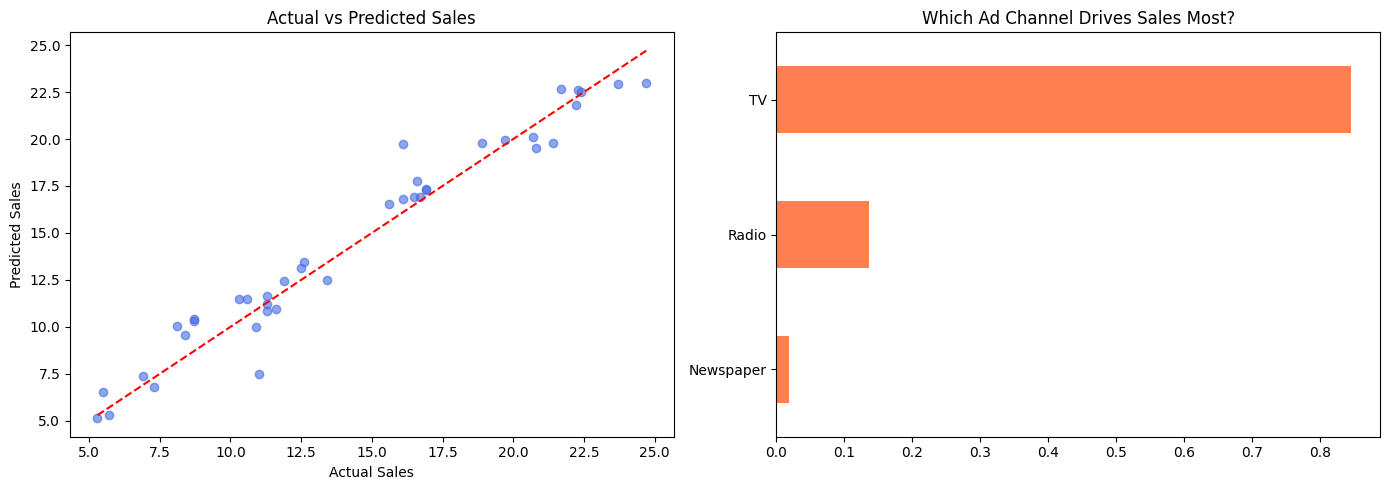

🎉 Task 4 Complete!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds, alpha=0.6, color='royalblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Actual vs Predicted Sales')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Which Ad Channel Drives Sales Most?')

plt.tight_layout()
plt.savefig('sales_results.png', dpi=150)
plt.show()
print("🎉 Task 4 Complete!")